Importation des bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modélisation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline

import warnings
warnings.filterwarnings('ignore') # Pour éviter les messages d'avertissement inutiles

Chargement des données préparées

In [3]:
PATH = '/kaggle/input/notebooks/yasminabouziane/data-rainprediction/' 

print("Chargement des données en cours...")
X_train = pd.read_csv(PATH + 'X_train.csv')
X_test = pd.read_csv(PATH + 'X_test.csv')
y_train = pd.read_csv(PATH + 'y_train.csv').values.ravel() # .values.ravel() pour mettre au bon format
y_test = pd.read_csv(PATH + 'y_test.csv').values.ravel()

print(f"Dimensions X_train : {X_train.shape}")
print(f"Dimensions X_test : {X_test.shape}")

Chargement des données en cours...
Dimensions X_train : (113754, 115)
Dimensions X_test : (28439, 115)


Construction du Pipeline et Tuning des hyperparamètres

In [4]:
# 1. Définition des composants
smote = SMOTE(random_state=42)
log_reg = LogisticRegression(max_iter=1000, random_state=42) # max_iter élevé car la convergence peut être longue

# 2. Création du Pipeline (SMOTE -> Régression Logistique)
pipeline_lr = imbpipeline(steps=[('smote', smote), ('model', log_reg)])

# 3. Paramètres à tester pour le Tuning (GridSearch)
# C est l'inverse de la force de régularisation (pour éviter le sur-apprentissage)
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'lbfgs']
}

# 4. Configuration de la recherche avec validation croisée
grid_search = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid,
    scoring='roc_auc', # On optimise l'aire sous la courbe
    cv=5, # Validation croisée à 5 plis
    n_jobs=-1,
    verbose=1
)

print("Lancement de l'entraînement et du tuning (cela peut prendre quelques minutes)...")
grid_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres trouvés : {grid_search.best_params_}")

Lancement de l'entraînement et du tuning (cela peut prendre quelques minutes)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Meilleurs paramètres trouvés : {'model__C': 0.01, 'model__solver': 'liblinear'}


Évaluation du modèle (ROC-AUC et Rapport)

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     22064
           1       0.61      0.67      0.64      6375

    accuracy                           0.83     28439
   macro avg       0.76      0.77      0.76     28439
weighted avg       0.84      0.83      0.83     28439



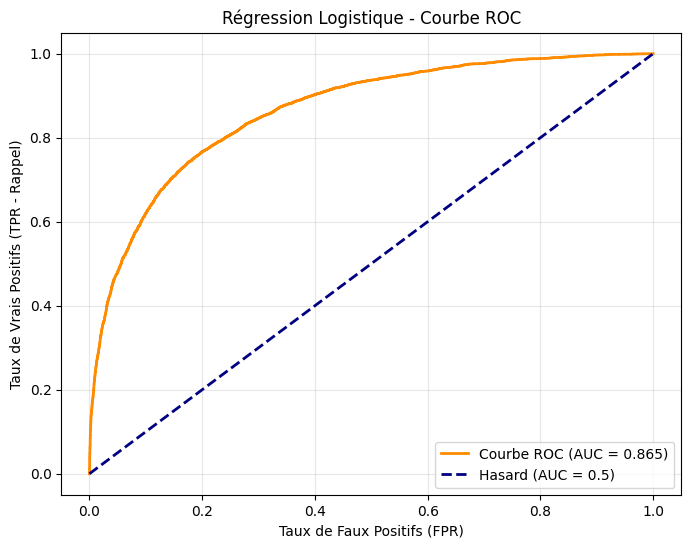

In [5]:
# On récupère le meilleur modèle
best_model = grid_search.best_estimator_

# Prédictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] # Probabilités pour la classe "Pluie" (1)

# 1. Rapport de classification
print("--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred))

# 2. Courbe ROC et AUC
auc_score = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR - Rappel)')
plt.title('Régression Logistique - Courbe ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Interprétabilité

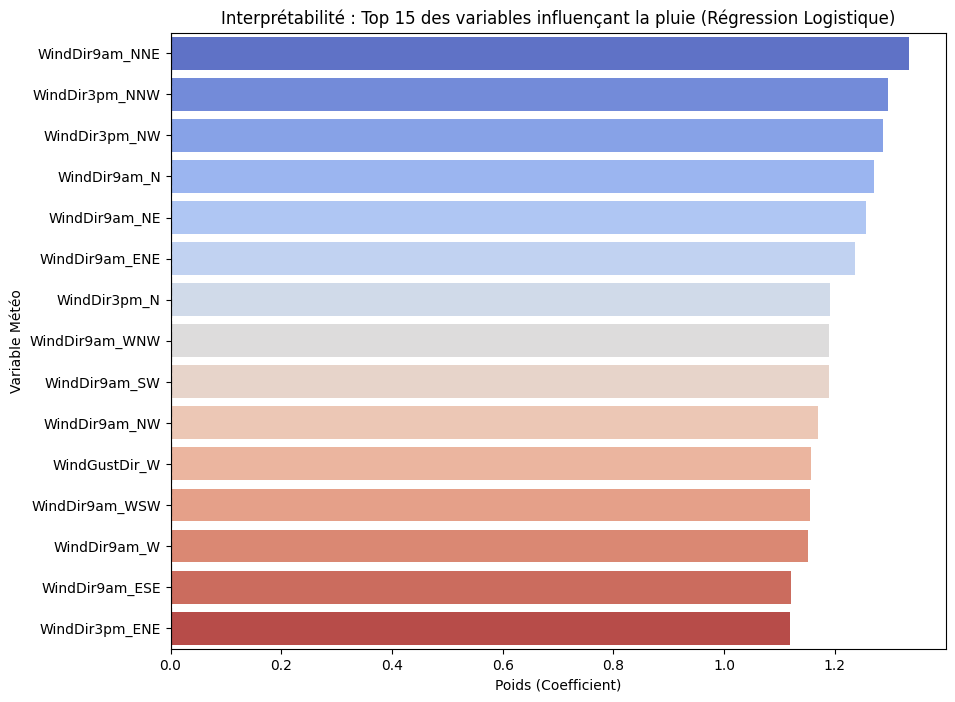


Lecture du graphique :
- Un coefficient positif élevé (rouge) augmente fortement la probabilité de pluie.
- Un coefficient négatif élevé (bleu) diminue fortement la probabilité de pluie.


In [6]:
# Extraction du modèle final depuis le pipeline
log_reg_final = best_model.named_steps['model']

# Récupération des coefficients
coefficients = log_reg_final.coef_[0]
features = X_train.columns

# Création d'un DataFrame pour la visualisation
feat_imp = pd.DataFrame({'Variable': features, 'Coefficient': coefficients})

# Tri par valeur absolue (pour voir l'impact global, positif ou négatif)
feat_imp['Valeur_Absolue'] = feat_imp['Coefficient'].abs()
feat_imp = feat_imp.sort_values(by='Valeur_Absolue', ascending=False).head(15) # Les 15 plus importantes

# Visualisation
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Variable', data=feat_imp, palette='coolwarm')
plt.title('Interprétabilité : Top 15 des variables influençant la pluie (Régression Logistique)')
plt.xlabel('Poids (Coefficient)')
plt.ylabel('Variable Météo')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

print("\nLecture du graphique :")
print("- Un coefficient positif élevé (rouge) augmente fortement la probabilité de pluie.")
print("- Un coefficient négatif élevé (bleu) diminue fortement la probabilité de pluie.")